# Framing Results — Delegitimization Rate and Hit Breakdown

Loads the GPT-5.4-mini frame classifications (11,975 windows across 7 outlets, 6 categories) and computes the **delegitimization rate** per outlet — the share of mentions classified into any of the four bias frames (agenda/allegiance, distortion/manipulation, disinformation/falsehood, failure/incompetence) versus neutral or irrelevant. Includes outlet-level breakdowns and the qualitative hit summaries used in the thesis.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("media_framing_final_run_5_4mini_classifications.csv")

# Normalize column names (strip whitespace, fix any typos)
df = df.rename(columns=lambda x: x.strip())
df = df.rename(columns={"suorce": "source", "categorty": "category"})

# Rename outlets to display names
OUTLET_RENAME = {
    "RT_de":           "RT DE",
    "Tichys_Einblick": "Tichys Einblick",
    "Nius":            "NIUS",
}
df["source"] = df["source"].replace(OUTLET_RENAME)

print(f"Loaded {len(df):,} rows  |  {df['source'].nunique()} outlets  |  {df['category'].nunique()} categories")
print(df["category"].value_counts())


Loaded 11,975 rows  |  7 outlets  |  6 categories
category
NEUTRAL                             8837
VERZERRUNG/MANIPULATION             1301
POSITIONS-/PARTEILICHKEITS-BIAS      848
DISINFORMATION/FALSCHDARSTELLUNG     343
VERSAGEN/INKOMPETENZ                 337
IRRELEVANT                           309
Name: count, dtype: int64


In [5]:
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams.update({
    "figure.dpi":        150,
    "font.family":       "sans-serif",
    "font.size":         11,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         False,
    "grid.alpha":        0.35,
    "axes.titlesize":    12,
    "axes.titleweight":  "bold",
    "axes.labelsize":    12,
    "xtick.labelsize":   12,
    "ytick.labelsize":   12,
    "legend.fontsize":   12,
    "legend.frameon":    True,
    "savefig.bbox":      "tight",
    "savefig.dpi":       300,
})

Filter out Irrelevant

In [6]:
# ── Apply all filters once ───────────────────────────────────────────────────
# Remove IRRELEVANT classifications and Tagesschau (reference outlet, not target)
print(f"Before filtering:  {len(df):,} rows")

df = df[
    (df["category"] != "IRRELEVANT") 
].copy()

print(f"After filtering:   {len(df):,} rows")
print(f"Sources remaining: {sorted(df['source'].unique())}")


Before filtering:  11,975 rows
After filtering:   11,666 rows
Sources remaining: ['Antispiegel', 'Compact', 'Deutschlandkurier', 'NIUS', 'RT DE', 'Tagesschau', 'Tichys Einblick']


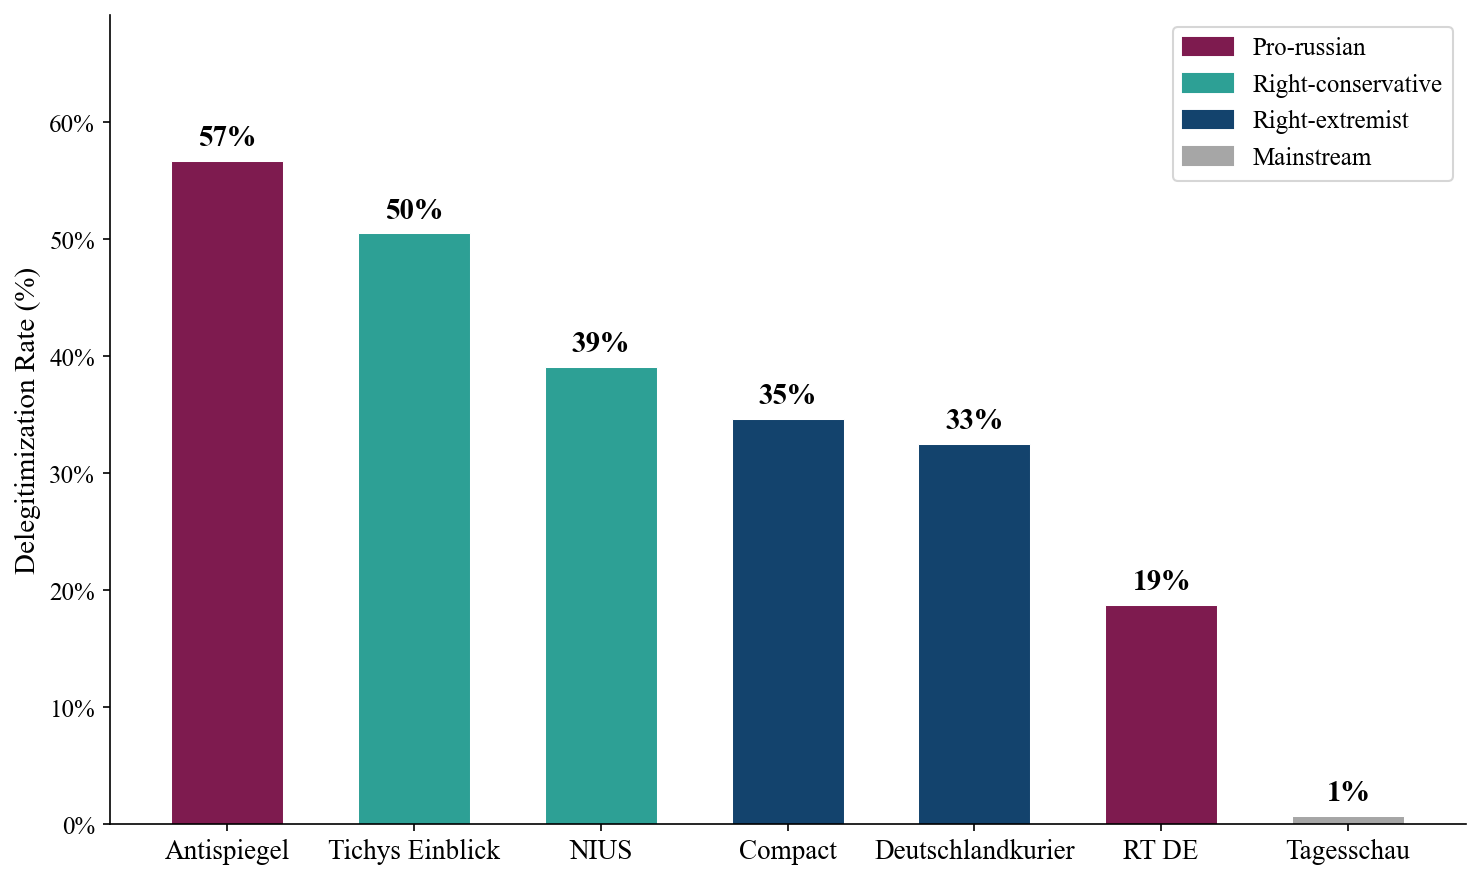

In [7]:
# ── Delegitimisation rate per outlet (incl. Tagesschau as reference) ──────────
# Computed on df AFTER removing IRRELEVANT, BEFORE removing Tagesschau

import matplotlib as mpl
mpl.rcParams["font.family"] = "Times New Roman"

OUTLET_GROUPS = {
    "RT DE":             {"label": "RT DE",            "color": "#7e1b4f", "group": "Pro-russian"},
    "Antispiegel":       {"label": "Antispiegel",       "color": "#7e1b4f", "group": "Pro-russian"},
    "Deutschlandkurier": {"label": "Deutschlandkurier", "color": "#13436d", "group": "Right-extremist"},
    "Compact":           {"label": "Compact",           "color": "#13436d", "group": "Right-extremist"},
    "NIUS":              {"label": "NIUS",              "color": "#2da095", "group": "Right-conservative"},
    "Tichys Einblick":   {"label": "Tichys Einblick",  "color": "#2da095", "group": "Right-conservative"},
    "Tagesschau":        {"label": "Tagesschau",        "color": "#a6a6a6", "group": "Mainstream"},
}

total_hits   = df.groupby("source").size()
framing_hits = df[df["category"] != "NEUTRAL"].groupby("source").size()
deleg_rate   = (framing_hits / total_hits).dropna()

plot_data = (
    deleg_rate
    .rename("rate")
    .reset_index()
    .rename(columns={"source": "outlet"})
    .assign(
        label = lambda d: d["outlet"].map(lambda o: OUTLET_GROUPS.get(o, {}).get("label", o)),
        color = lambda d: d["outlet"].map(lambda o: OUTLET_GROUPS.get(o, {}).get("color", "#aaaaaa")),
        group = lambda d: d["outlet"].map(lambda o: OUTLET_GROUPS.get(o, {}).get("group", "Other")),
    )
)
plot_data = (
    plot_data[plot_data["outlet"].isin(OUTLET_GROUPS)]
    .sort_values("rate", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(
    plot_data["label"], plot_data["rate"] * 100,
    color=plot_data["color"], edgecolor="white", linewidth=0.5, width=0.6
)
for bar, (_, row) in zip(bars, plot_data.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.8,
        f"{row['rate']*100:.0f}%",
        ha="center", va="bottom", fontsize=14, fontweight="bold",
        fontfamily="Times New Roman"
    )

ax.set_ylabel("Delegitimization Rate (%)", fontsize=14)
ax.set_ylim(0, max(plot_data["rate"] * 100) * 1.22)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.tick_params(axis="x", labelsize=13)
ax.tick_params(axis="y", labelsize=12)

ax.yaxis.grid(False)
ax.xaxis.grid(False)
ax.set_axisbelow(False)
ax.spines[["top", "right"]].set_visible(False)

from matplotlib.patches import Patch
seen = {}
for _, row in plot_data.iterrows():
    if row["group"] not in seen:
        seen[row["group"]] = row["color"]
ax.legend(
    handles=[Patch(color=c, label=g) for g, c in seen.items()],
    frameon=True, loc="upper right",
    prop={"family": "Times New Roman", "size": 12}
)
plt.tight_layout()
plt.show()


# Filter out Tagesschau

In [8]:
# ── Apply all filters once ───────────────────────────────────────────────────
# Remove IRRELEVANT classifications and Tagesschau (reference outlet, not target)
print(f"Before filtering:  {len(df):,} rows")

df = df[
    (df["source"] != "Tagesschau") 
].copy()

print(f"After filtering:   {len(df):,} rows")
print(f"Sources remaining: {sorted(df['source'].unique())}")

Before filtering:  11,666 rows
After filtering:   7,339 rows
Sources remaining: ['Antispiegel', 'Compact', 'Deutschlandkurier', 'NIUS', 'RT DE', 'Tichys Einblick']


In [9]:
df["category"].value_counts()


category
NEUTRAL                             4541
VERZERRUNG/MANIPULATION             1290
POSITIONS-/PARTEILICHKEITS-BIAS      838
DISINFORMATION/FALSCHDARSTELLUNG     340
VERSAGEN/INKOMPETENZ                 330
Name: count, dtype: int64

In [10]:
df["source"].value_counts()


source
Tichys Einblick      2208
NIUS                 1969
RT DE                1815
Antispiegel           513
Compact               456
Deutschlandkurier     378
Name: count, dtype: int64

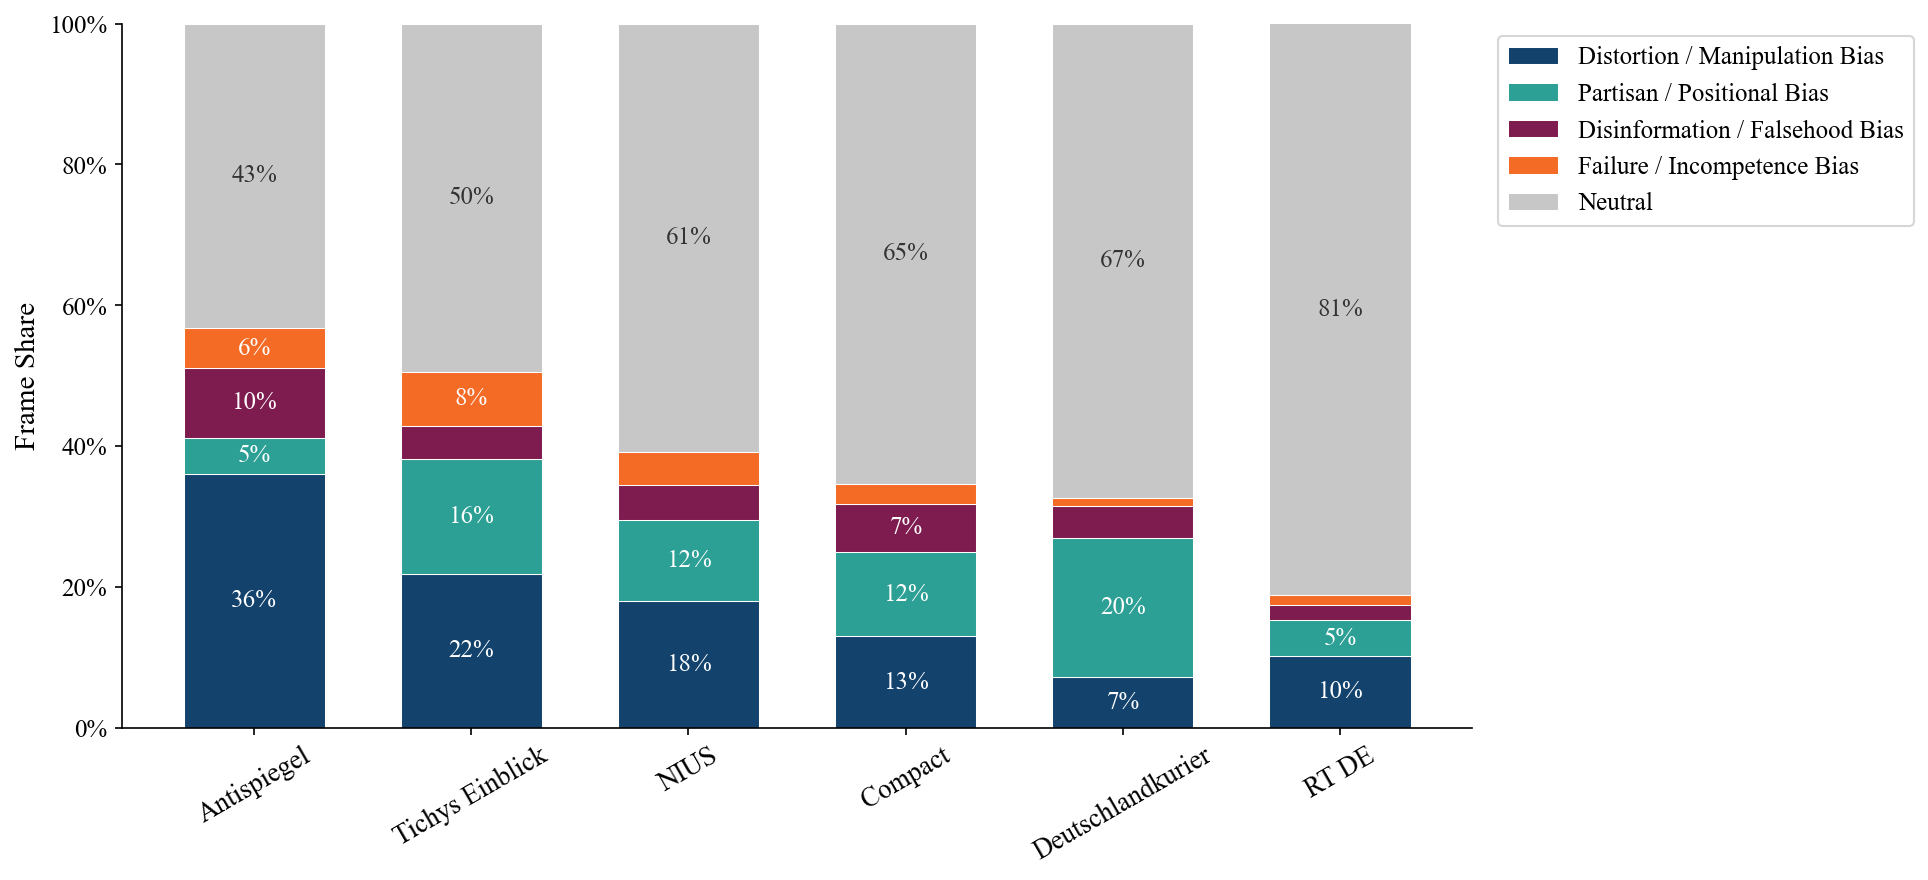

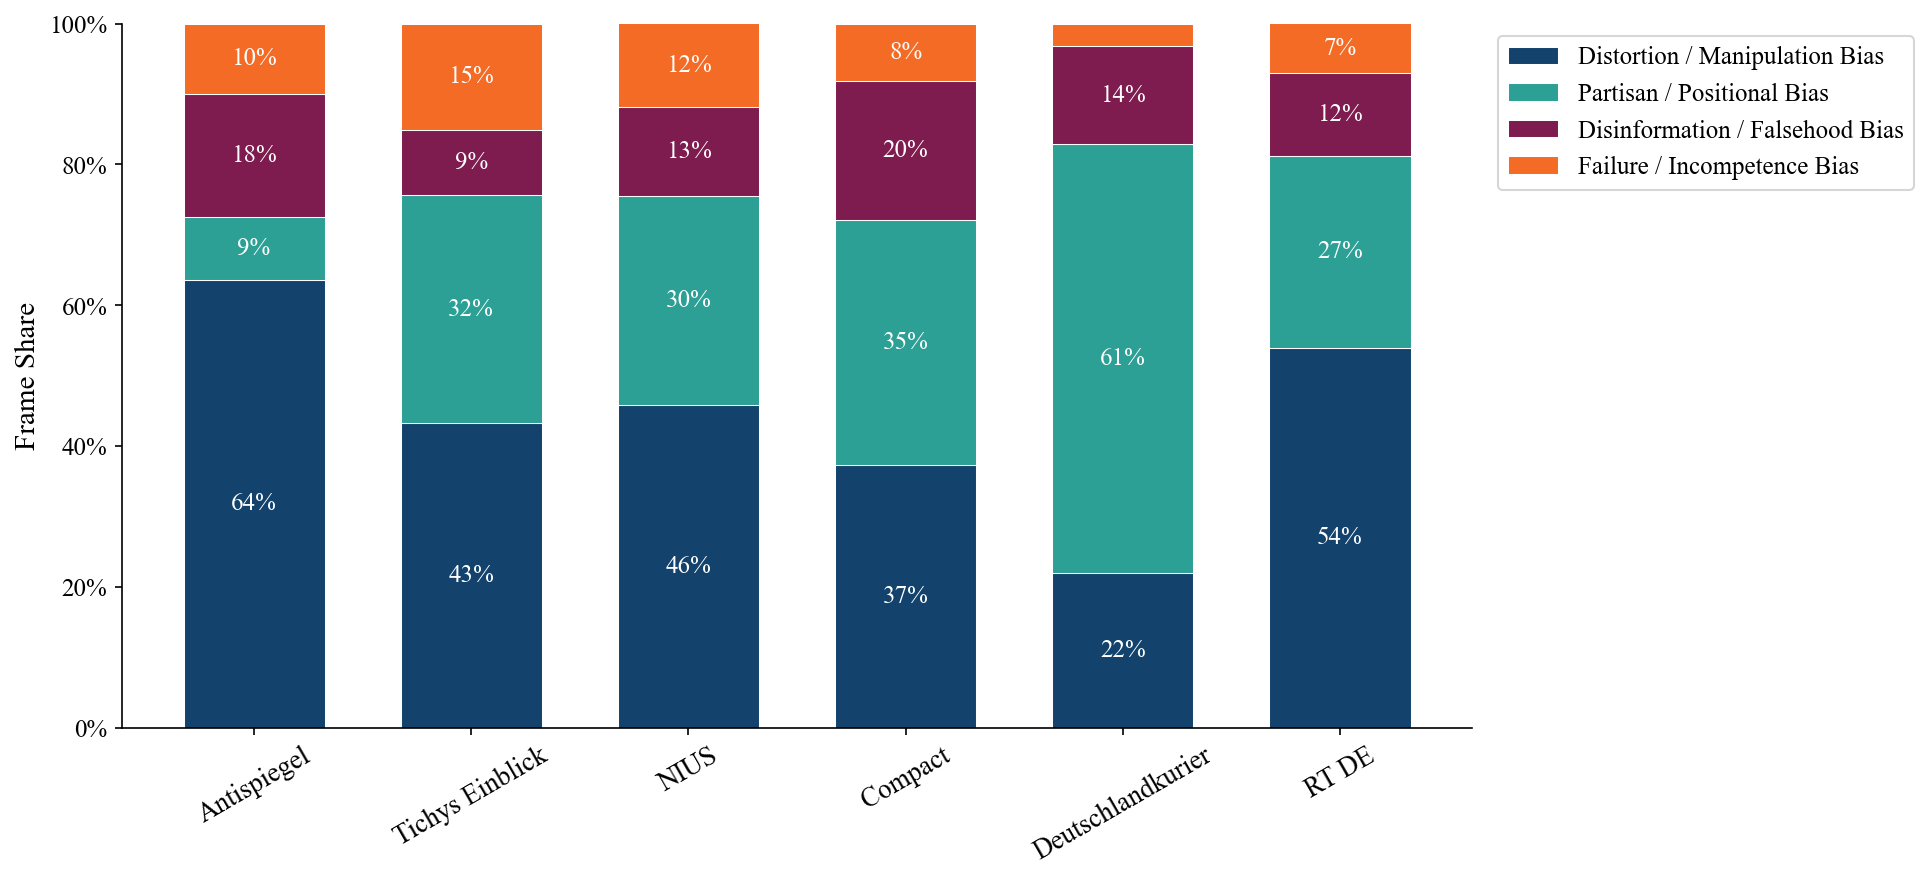

In [11]:
# ── Stacked bar: frame category mix per outlet ───────────────────────────────
import matplotlib as mpl
mpl.rcParams["font.family"] = "Times New Roman"

CATEGORY_EN = {
    "VERZERRUNG/MANIPULATION":            "Distortion / Manipulation Bias",
    "POSITIONS-/PARTEILICHKEITS-BIAS":    "Partisan / Positional Bias",
    "DISINFORMATION/FALSCHDARSTELLUNG":   "Disinformation / Falsehood Bias",
    "VERSAGEN/INKOMPETENZ":               "Failure / Incompetence Bias",
    "NEUTRAL":                            "Neutral",
}
FRAMING_COLS = [
    "Distortion / Manipulation Bias",
    "Partisan / Positional Bias",
    "Disinformation / Falsehood Bias",
    "Failure / Incompetence Bias",
]
FRAME_COLORS = {
    "Distortion / Manipulation Bias":  "#13436d",
    "Partisan / Positional Bias":      "#2da095",
    "Disinformation / Falsehood Bias": "#7e1b4f",
    "Failure / Incompetence Bias":     "#f46b26",
    "Neutral":                   "#c7c7c7",
}

# Outlet group colors for x-axis tick labels
OUTLET_GROUP_COLORS = {
    "RT DE":            "#7e1b4f",
    "Antispiegel":      "#7e1b4f",
    "Deutschlandkurier":"#13436d",
    "Compact":          "#13436d",
    "NIUS":             "#2da095",
    "Tichys Einblick":  "#2da095",
}

df["category_en"] = df["category"].map(CATEGORY_EN)

ALL_COLS = FRAMING_COLS + ["Neutral"]
counts_all = (
    df[df["category_en"].notna()]
    .groupby(["source", "category_en"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=ALL_COLS, fill_value=0)
)
outlet_order = (
    counts_all[FRAMING_COLS].sum(axis=1) / counts_all.sum(axis=1)
).sort_values(ascending=False).index

def stacked_bar(ax, props, col_order):
    bottoms = np.zeros(len(props))
    for frame in col_order:
        vals = props[frame].values
        ax.bar(props.index, vals, bottom=bottoms, color=FRAME_COLORS[frame],
               label=frame, width=0.65, edgecolor="white", linewidth=0.5)
        for i, (v, b) in enumerate(zip(vals, bottoms)):
            if v > 0.05:
                ax.text(i, b + v / 2, f"{v:.0%}", ha="center", va="center",
                        fontsize=12, color="white" if frame != "Neutral" else "#333")
        bottoms += vals
    ax.set_ylim(0, 1)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.0%}"))
    ax.set_ylabel("Frame Share", fontsize=14)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=30, labelsize=13)
    ax.tick_params(axis="y", labelsize=12)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(loc="upper left", bbox_to_anchor=(1.01, 1), frameon=True, fontsize=12)
    # x-axis tick labels: black
    for tick in ax.get_xticklabels():
        tick.set_color("black")

# Chart 1: framing + Neutral
props_all = counts_all.div(counts_all.sum(axis=1), axis=0).loc[outlet_order]
fig, ax = plt.subplots(figsize=(13, 6))
stacked_bar(ax, props_all, ALL_COLS)
plt.tight_layout()
plt.show()

# Chart 2: framing only
counts_framing = counts_all[FRAMING_COLS].loc[outlet_order]
props_framing  = counts_framing.div(counts_framing.sum(axis=1), axis=0)
fig, ax = plt.subplots(figsize=(13, 6))
stacked_bar(ax, props_framing, FRAMING_COLS)
plt.tight_layout()
plt.show()


## Hit Analysis

In [12]:
# Split combined hit_text entries like "ARD | ZDF | Spiegel" into one row each
df = (
    df.assign(hit_text=df["hit_text"].str.split(r"\s*\|\s*"))
    .explode("hit_text")
    .assign(hit_text=lambda d: d["hit_text"].str.strip())
)

print(f"Rows after splitting combined hits: {len(df):,}")
print()
print(df["hit_text"].value_counts().head(30))


Rows after splitting combined hits: 9,616

hit_text
ZDF                               1141
ARD                                966
Spiegel                            932
Markus Lanz                        444
Reuters                            437
Tagesschau                         413
Politico                           385
FAZ                                335
ÖRR                                321
taz                                268
Handelsblatt                       241
NDR                                234
Berliner Zeitung                   226
Bild                               222
Tagesspiegel                       217
Stern                              198
WDR                                187
Süddeutsche Zeitung                186
Deutschlandfunk                    175
Jan Böhmermann                     172
dpa                                152
The European                       135
rbb                                133
RND                                129
SWR         

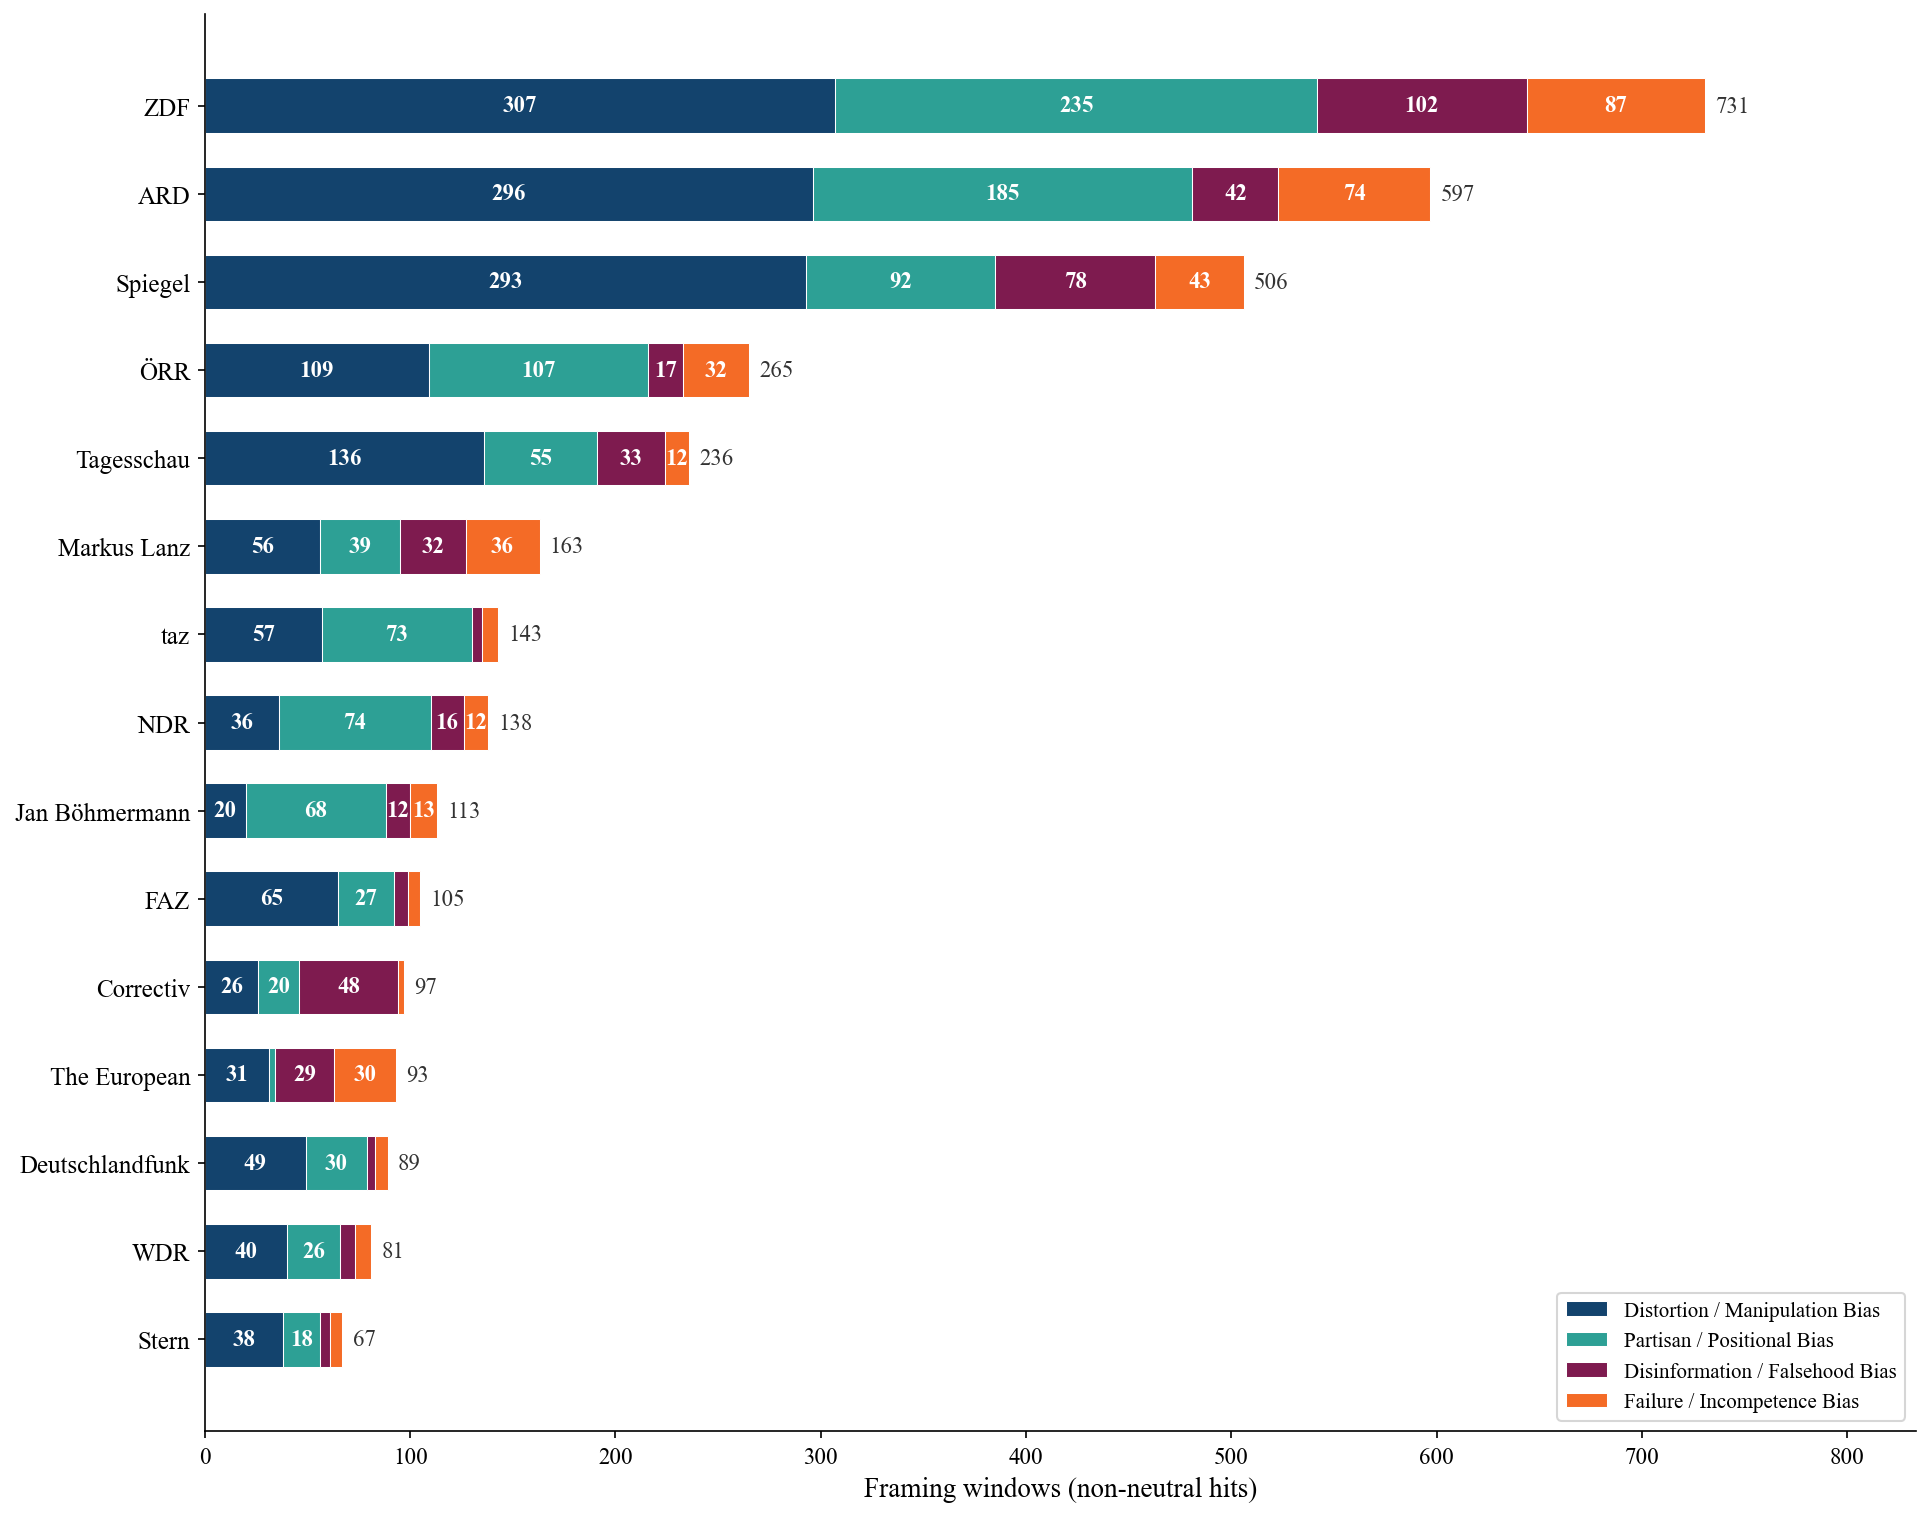

In [13]:
# ── Top 15 most-criticised entities: stacked by frame category ───────────────
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
mpl.rcParams["font.family"] = "Times New Roman"

TOP_ENTITIES = 15

CATEGORY_BIAS = {
    "VERZERRUNG/MANIPULATION":            "Distortion / Manipulation Bias",
    "POSITIONS-/PARTEILICHKEITS-BIAS":    "Partisan / Positional Bias",
    "DISINFORMATION/FALSCHDARSTELLUNG":   "Disinformation / Falsehood Bias",
    "VERSAGEN/INKOMPETENZ":               "Failure / Incompetence Bias",
}
FRAME_ORDER = [
    "Distortion / Manipulation Bias",
    "Partisan / Positional Bias",
    "Disinformation / Falsehood Bias",
    "Failure / Incompetence Bias",
]
FRAME_COLORS_BIAS = {
    "Distortion / Manipulation Bias":  "#13436d",
    "Partisan / Positional Bias":      "#2da095",
    "Disinformation / Falsehood Bias": "#7e1b4f",
    "Failure / Incompetence Bias":     "#f46b26",
}

# Non-neutral rows only, with exploded hit_text already in df
df_bias = df[df["category"].isin(CATEGORY_BIAS)].copy()
df_bias["frame"] = df_bias["category"].map(CATEGORY_BIAS)

# Count per entity x frame
entity_frame = (
    df_bias.groupby(["hit_text", "frame"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=FRAME_ORDER, fill_value=0)
)

# Top N by total, sorted ascending so largest is at top of horizontal bar chart
totals = entity_frame.sum(axis=1)
top_entities = totals.nlargest(TOP_ENTITIES).index
entity_frame = entity_frame.loc[top_entities].iloc[::-1]  # reverse: largest at top
totals = entity_frame.sum(axis=1)

fig, ax = plt.subplots(figsize=(13, 0.55 * TOP_ENTITIES + 2))

lefts = np.zeros(len(entity_frame))
for frame in FRAME_ORDER:
    vals = entity_frame[frame].values
    ax.barh(entity_frame.index, vals, left=lefts,
            color=FRAME_COLORS_BIAS[frame], label=frame,
            height=0.62, edgecolor="white", linewidth=0.5)
    for i, (v, l) in enumerate(zip(vals, lefts)):
        if v >= 12:
            ax.text(l + v / 2, i, str(int(v)),
                    ha="center", va="center", fontsize=11,
                    color="white", fontweight="bold")
    lefts += vals

# Total label at end of each bar
for i, (total, left) in enumerate(zip(totals.values, lefts)):
    ax.text(left + 5, i, str(int(total)),
            ha="left", va="center", fontsize=11, color="#333333")

ax.set_xlabel("Framing windows (non-neutral hits)", fontsize=13)
ax.tick_params(axis="y", labelsize=12)
ax.tick_params(axis="x", labelsize=11)
ax.set_xlim(0, totals.max() * 1.14)
ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.grid(False)
ax.legend(loc="lower right", fontsize=10, frameon=True)
plt.tight_layout()
plt.show()


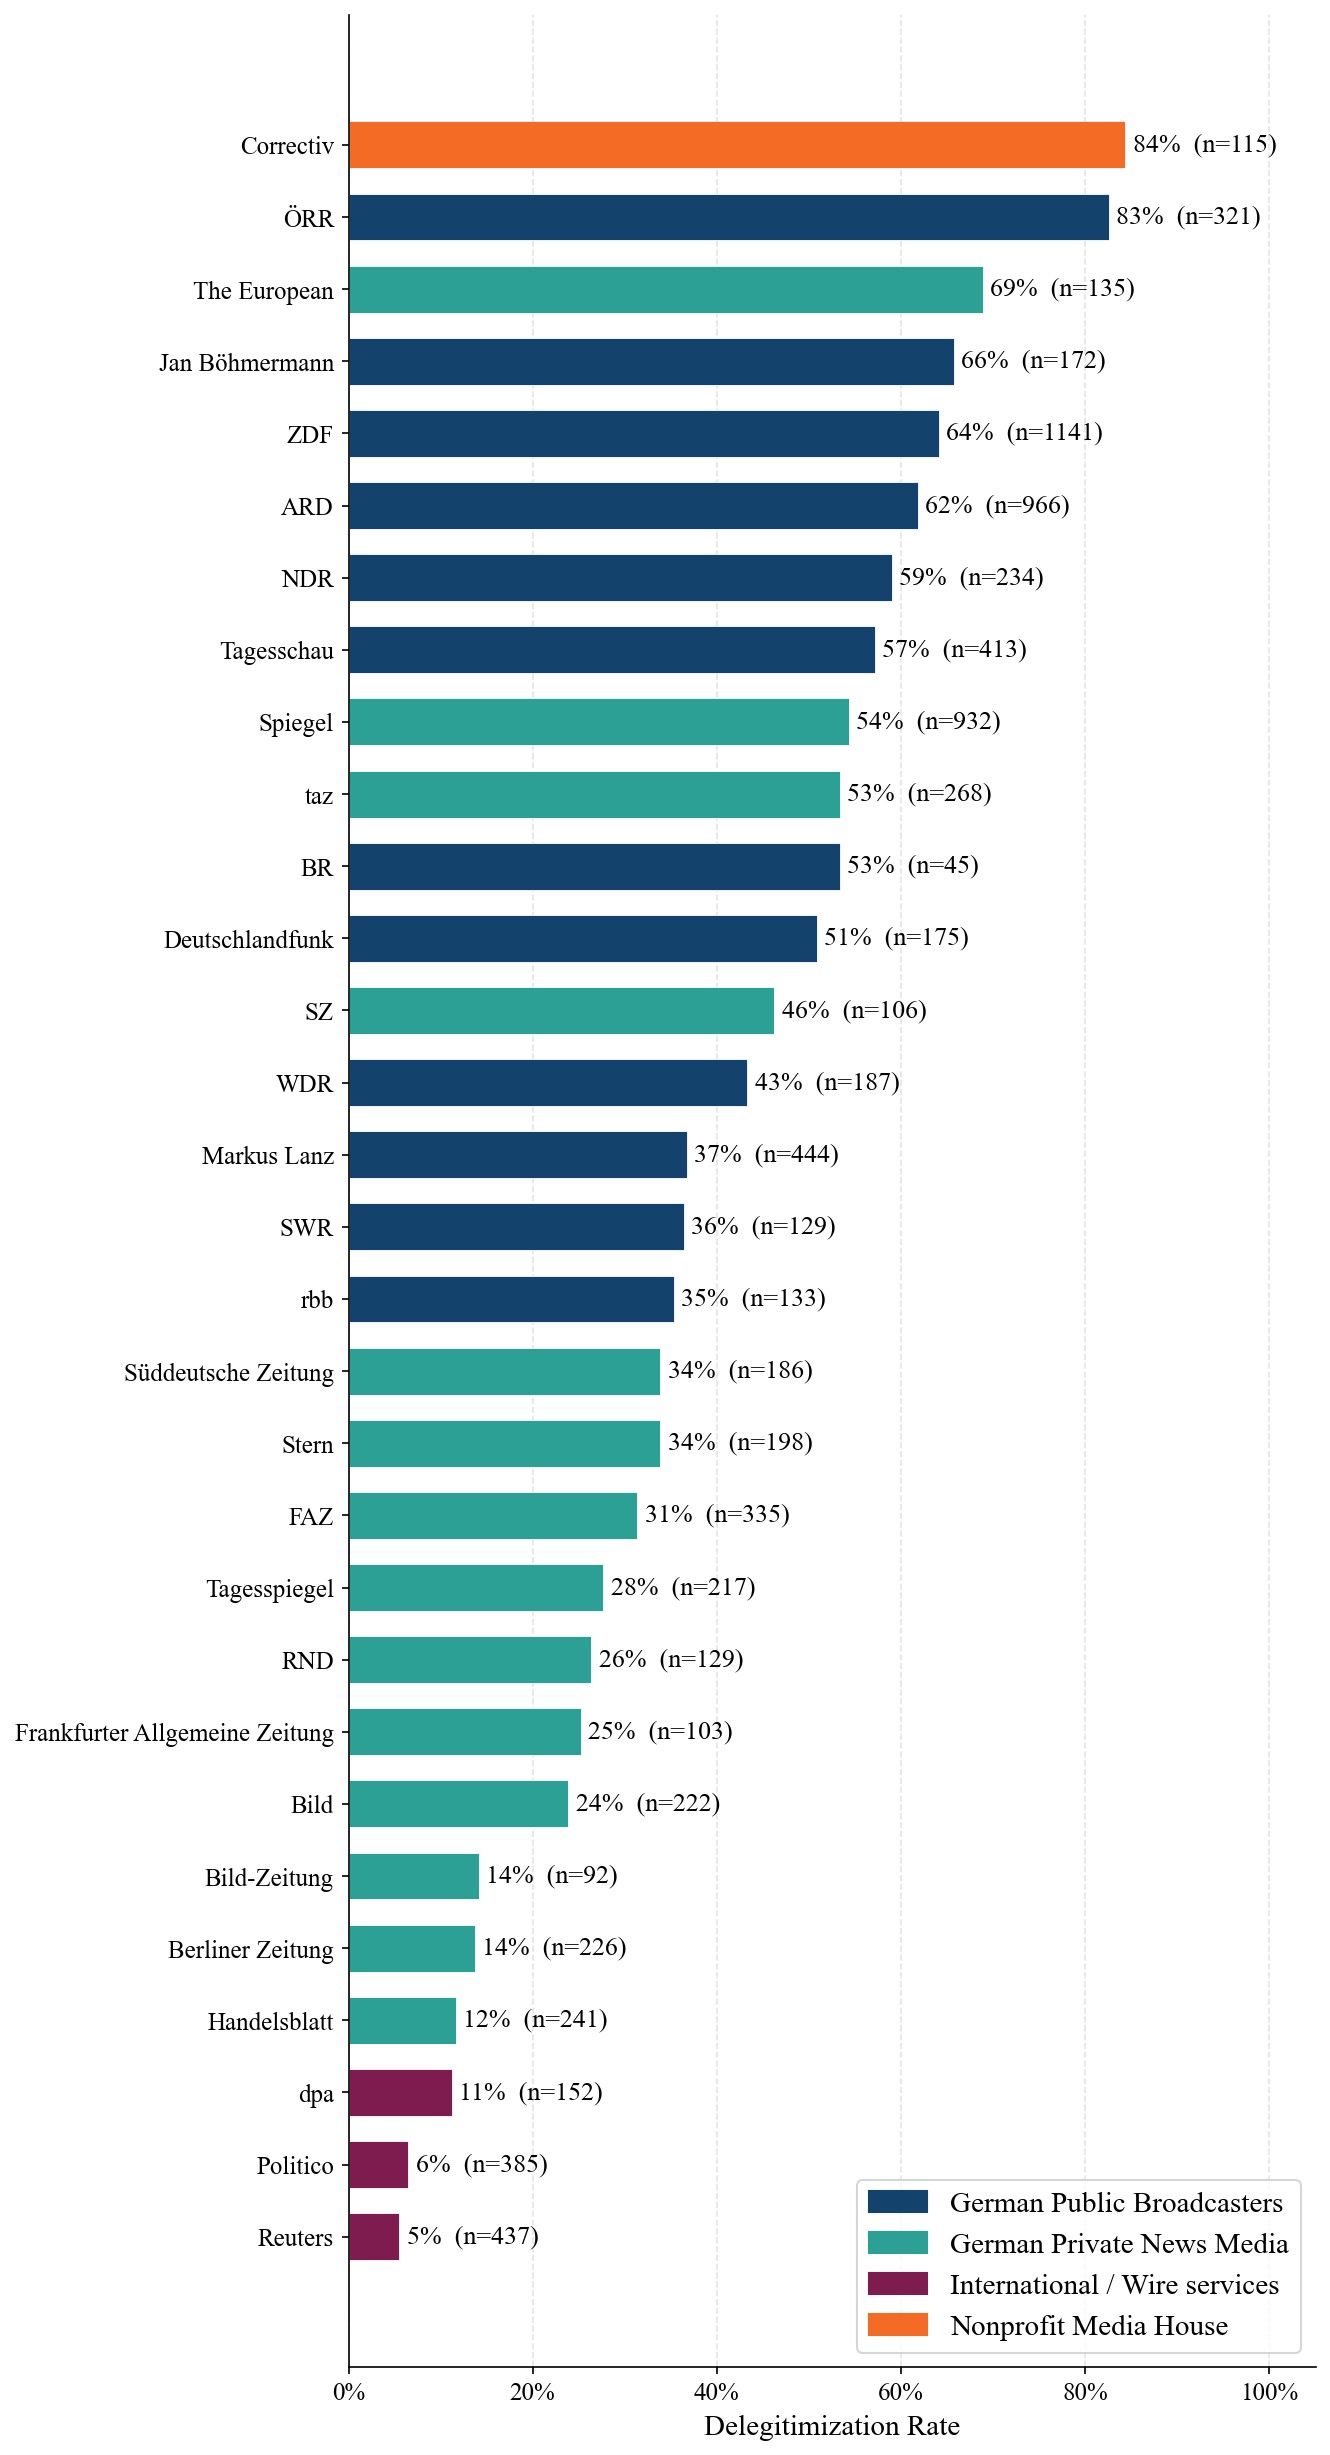

In [14]:
# ── Top 20 most-mentioned known entities: delegitimisation rate ───────────────
from matplotlib.patches import Patch

TOP_N = 30

HIT_GROUPS = {
    "German Public Broadcasters": {
        "color": "#13436d",
        "members": {
            "ÖRR", "ZDF", "ARD", "NDR", "SWR", "BR", "rbb", "WDR",
            "Tagesschau", "Deutschlandfunk", "Deutschlandradio",
            "Öffentlich-Rechtliche", "Öffentlich-rechtliche Medien",
            "ÖffentlichRechtliche", "Staatsfunk",
            "Jan Böhmermann", "Böhmermann", "Markus Lanz", "Lanz",
        },
    },
    "German Private News Media": {
        "color": "#2da095",
        "members": {
            "Spiegel", "Der Spiegel", "taz", "Süddeutsche Zeitung", "SZ",
            "Tagesspiegel", "Stern", "FAZ", "Frankfurter Allgemeine Zeitung",
            "Handelsblatt", "Bild", "Bild-Zeitung", "Berliner Zeitung",
            "RND", "Qualitätsmedien","The European",
        },
    },
    "International / Wire services": {
        "color": "#7e1b4f",
        "members": {"Politico", "Reuters", "BBC", "CNN", "AP", "dpa"},},

    "Nonprofit Media House":{"color": "#f46b26",
        "members": {"Correctiv",
        }
    },

}

hit_to_group = {m: g for g, meta in HIT_GROUPS.items() for m in meta["members"]}

df_known     = df[df["hit_text"].isin(hit_to_group)].copy()
total_hits   = df_known.groupby("hit_text").size()
framing_hits = df_known[df_known["category"] != "NEUTRAL"].groupby("hit_text").size()
deleg        = (framing_hits / total_hits).dropna().rename("rate")

top_entities = total_hits.nlargest(TOP_N).index
plot_df = (
    deleg.reindex(top_entities).dropna()
    .reset_index()
    .rename(columns={"hit_text": "entity"})
)
plot_df["n"]     = plot_df["entity"].map(total_hits).astype(int)
plot_df["group"] = plot_df["entity"].map(hit_to_group)
plot_df["color"] = plot_df["group"].map(lambda g: HIT_GROUPS[g]["color"])
plot_df = plot_df.sort_values("rate", ascending=True)

fig, ax = plt.subplots(figsize=(9, max(6, len(plot_df) * 0.55)))
bars = ax.barh(plot_df["entity"], plot_df["rate"] * 100,
               color=plot_df["color"], edgecolor="white", linewidth=0.4, height=0.65)
for bar, (_, row) in zip(bars, plot_df.iterrows()):
    pct = row["rate"] * 100
    ax.text(pct + 0.8, bar.get_y() + bar.get_height() / 2,
            f"{pct:.0f}%  (n={row['n']})", va="center", fontsize=12.5)

ax.set_xlabel("Delegitimization Rate", fontsize=14)
ax.set_xlim(0, 105)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.tick_params(axis="y", labelsize=12)
ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.grid(True, linestyle="--", alpha=0.35)
ax.set_axisbelow(True)
legend_handles = [
    Patch(color=meta["color"], label=group)
    for group, meta in HIT_GROUPS.items()
    if group in plot_df["group"].values
]
ax.legend(handles=legend_handles, loc="lower right", fontsize=14, frameon=True)
plt.tight_layout()
plt.show()


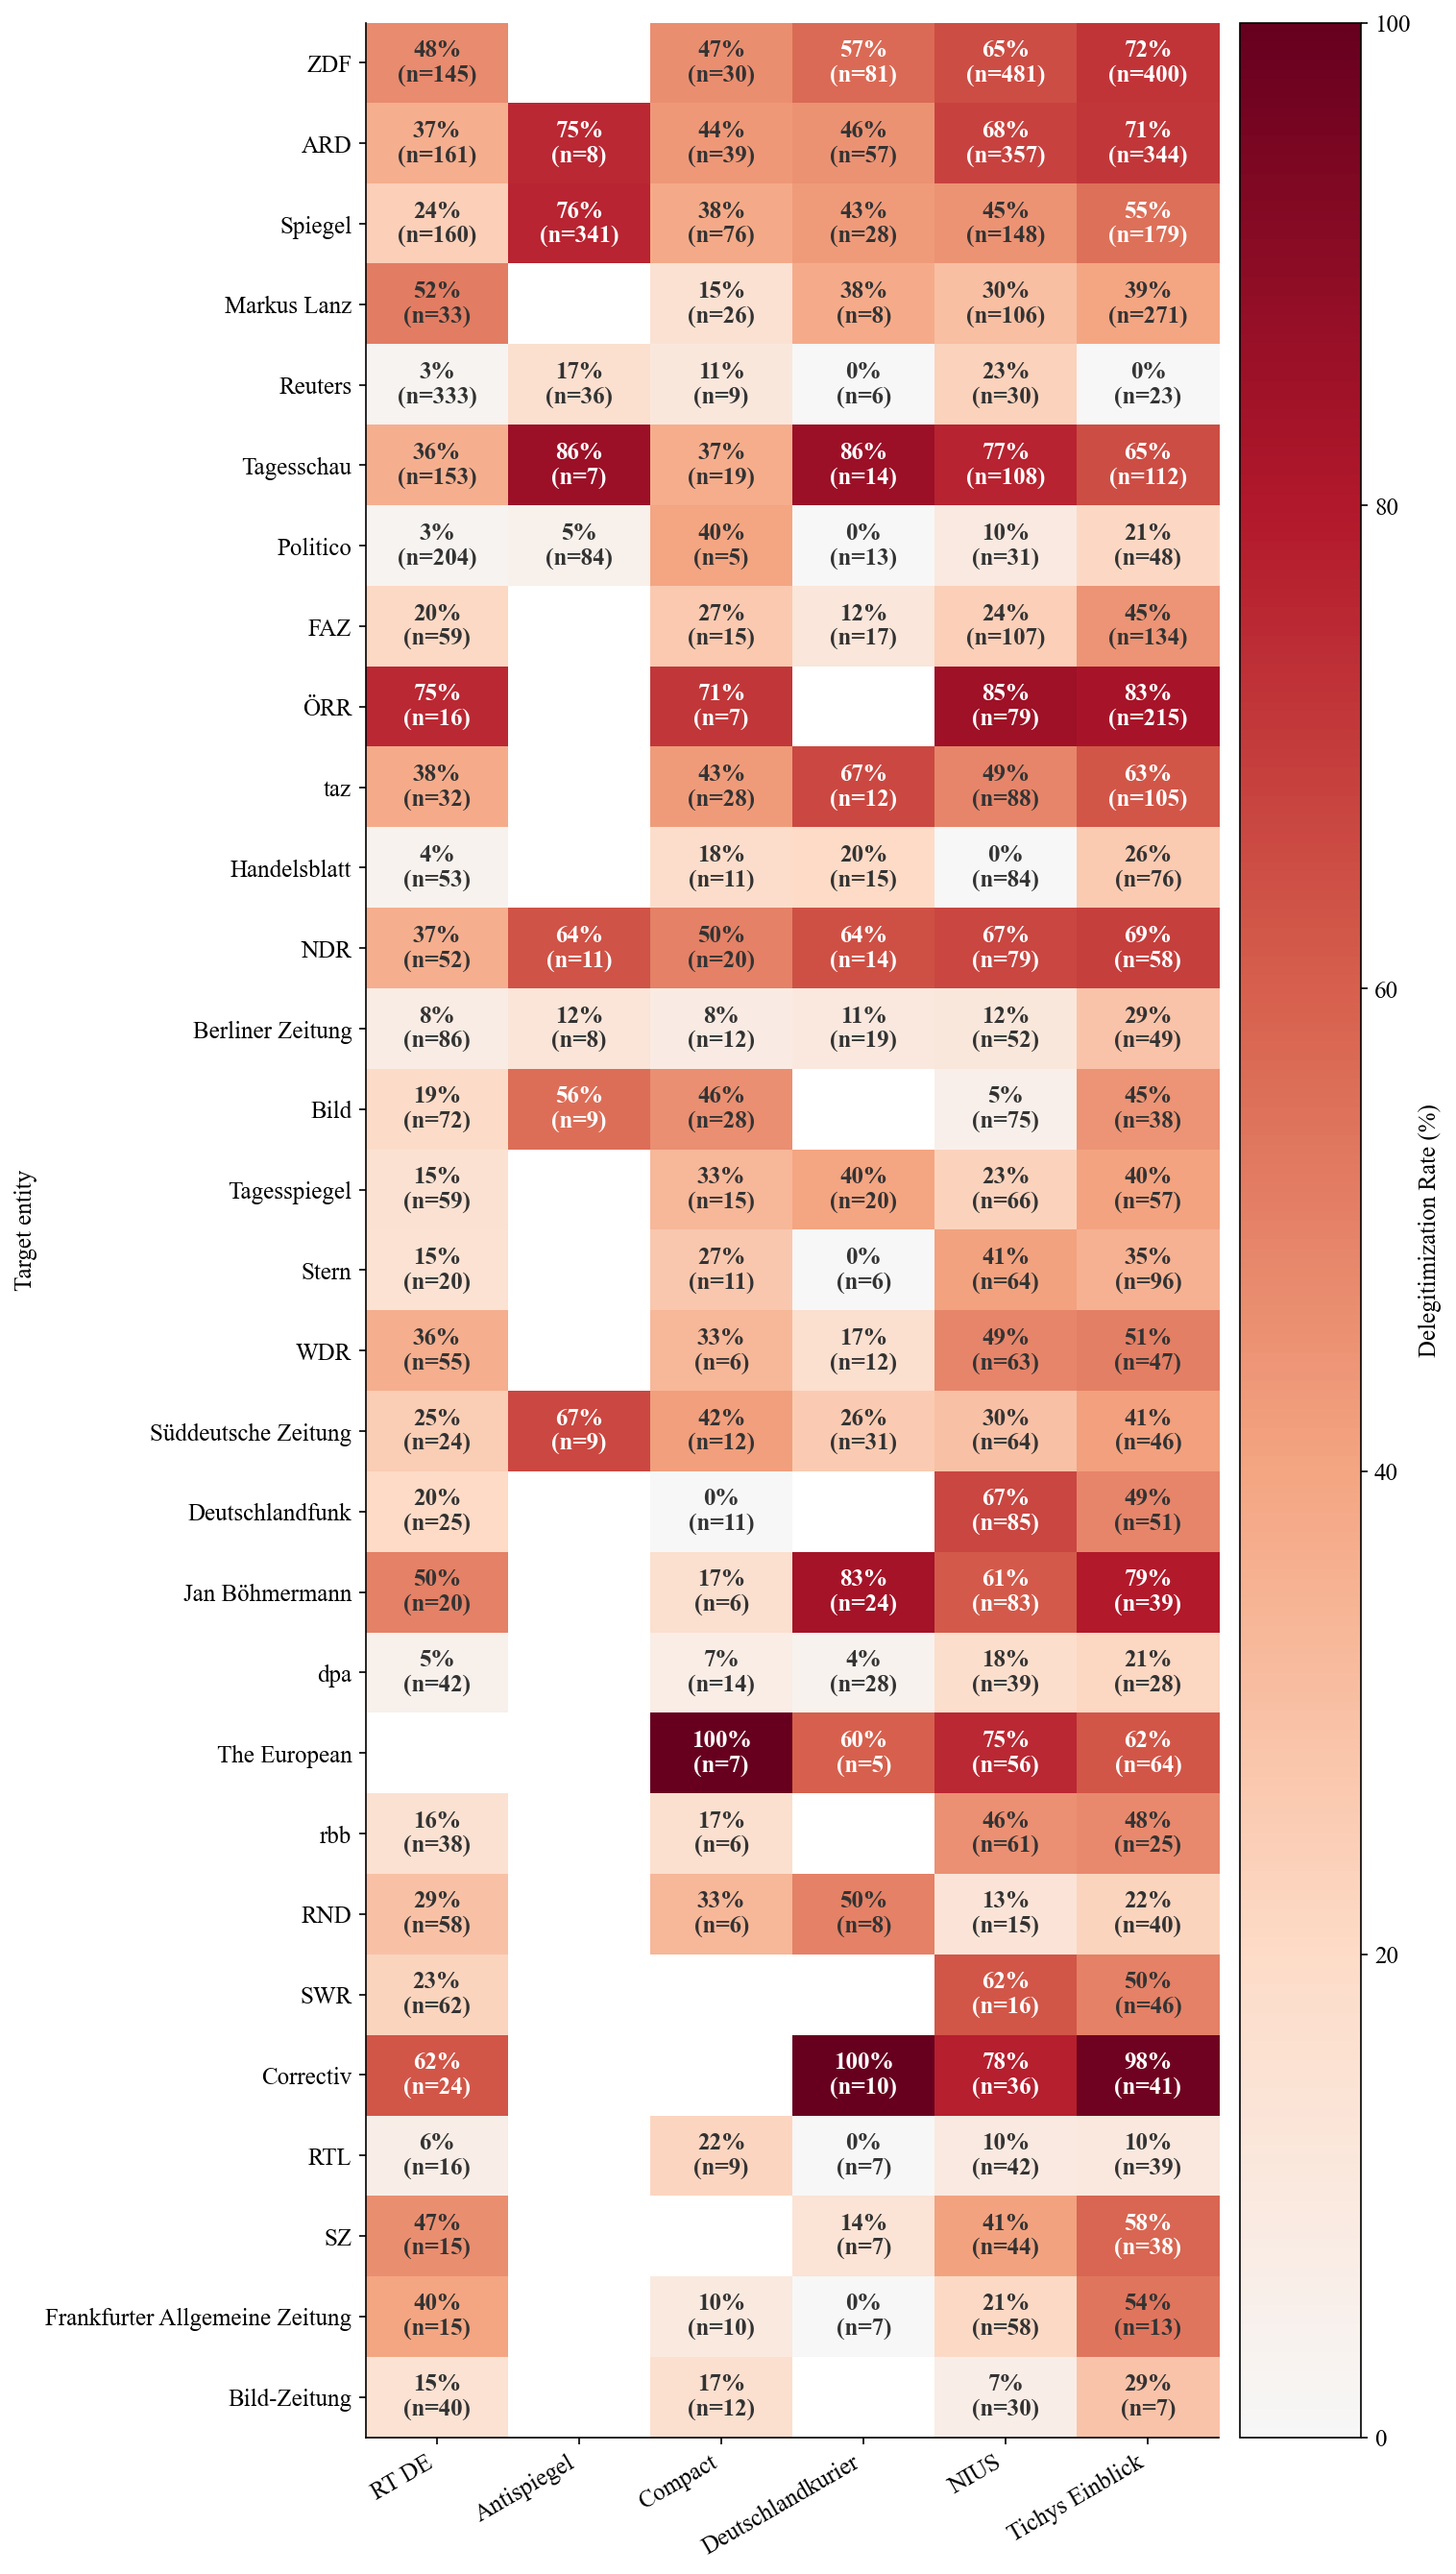

In [15]:
# ── Heatmap: delegitimisation rate per target entity × outlet ─────────────────
import matplotlib.colors as mcolors

MIN_N  = 5
TOP_N  = 30
OUTLETS = ["RT DE", "Antispiegel", "Compact", "Deutschlandkurier", "NIUS", "Tichys Einblick"]

top_entities = (
    df.groupby("hit_text").size()
    .nlargest(TOP_N)
    .index.tolist()
)

df_sub  = df[df["hit_text"].isin(top_entities) & df["source"].isin(OUTLETS)].copy()
total   = df_sub.groupby(["hit_text", "source"]).size().unstack(fill_value=0)
framing = (
    df_sub[df_sub["category"] != "NEUTRAL"]
    .groupby(["hit_text", "source"]).size()
    .unstack(fill_value=0)
)
total       = total.reindex(index=top_entities,   columns=OUTLETS, fill_value=0)
framing     = framing.reindex(index=top_entities, columns=OUTLETS, fill_value=0)
rate        = (framing / total.replace(0, np.nan)) * 100
rate_masked = rate.where(total >= MIN_N, other=np.nan)

from matplotlib.colors import LinearSegmentedColormap
# Sequential red scale (white → light red → deep red); no blue since values are 0–100%
THESIS_SEQ = LinearSegmentedColormap.from_list(
    "thesis_seq", ["#f7f7f7", "#fddbc7", "#f4a582", "#d6604d", "#b2182b", "#67001f"], N=256
)
cmap = THESIS_SEQ
norm = mcolors.Normalize(vmin=0, vmax=100)
fig, ax = plt.subplots(figsize=(max(10, len(OUTLETS) * 1.6), max(8, TOP_N * 0.6)))
im = ax.imshow(rate_masked.values, cmap=cmap, norm=norm, aspect="auto")

for r, entity in enumerate(rate_masked.index):
    for c, outlet in enumerate(rate_masked.columns):
        val = rate_masked.iloc[r, c]
        n   = total.iloc[r, c]
        if np.isnan(val):
            continue
        ax.text(c, r, f"{val:.0f}%\n(n={int(n)})",
                ha="center", va="center", fontsize=12, fontweight="bold",
                color="white" if val > 55 else "#333333")

ax.set_xticks(range(len(OUTLETS)))
ax.set_xticklabels(OUTLETS, rotation=30, ha="right", fontsize=12)
ax.set_yticks(range(len(rate_masked.index)))
ax.set_yticklabels(rate_masked.index, fontsize=12)
ax.set_ylabel("Target entity", fontsize=12)
fig.colorbar(im, ax=ax, pad=0.02).set_label("Delegitimization Rate (%)", fontsize=12)
plt.tight_layout()
plt.show()


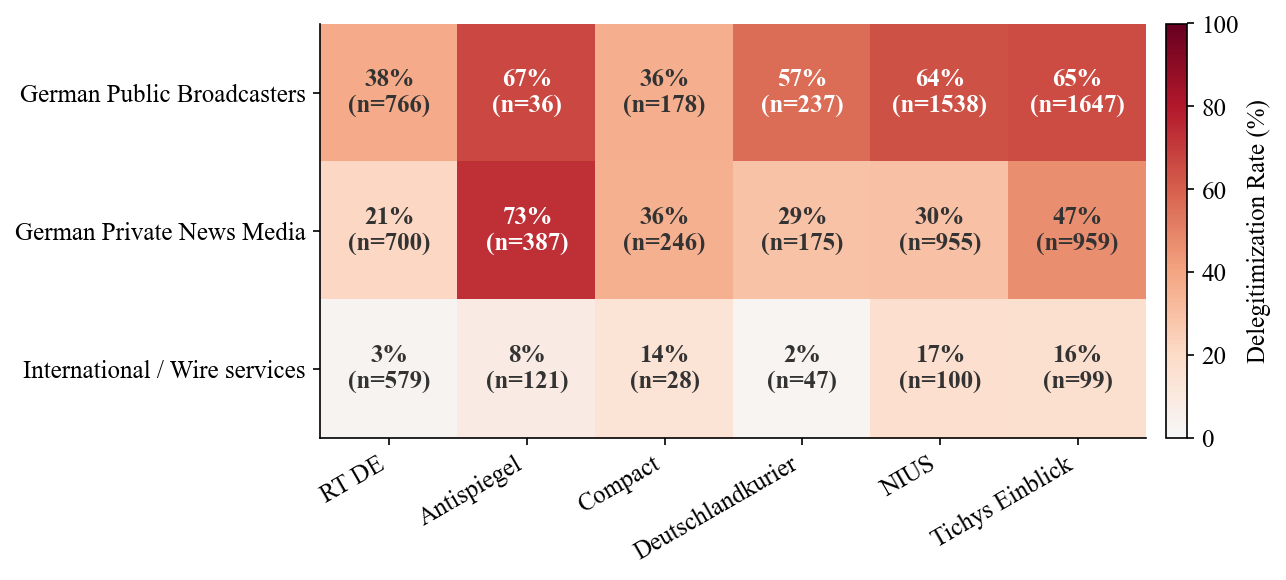

In [16]:
# ── Delegitimisation rate per hit GROUP × outlet ──────────────────────────────
df["hit_group"] = df["hit_text"].map(hit_to_group)
df_grp = df[df["hit_group"].notna() & df["source"].isin(OUTLETS)].copy()

total_g   = df_grp.groupby(["hit_group", "source"]).size().unstack(fill_value=0)
framing_g = (
    df_grp[df_grp["category"] != "NEUTRAL"]
    .groupby(["hit_group", "source"]).size()
    .unstack(fill_value=0)
)
group_order = [g for g in HIT_GROUPS.keys() if g != "Nonprofit Media House"]
total_g   = total_g.reindex(index=group_order,   columns=OUTLETS, fill_value=0)
framing_g = framing_g.reindex(index=group_order, columns=OUTLETS, fill_value=0)
rate_g    = (framing_g / total_g.replace(0, np.nan)) * 100
rate_vis  = rate_g.where(total_g >= MIN_N, other=np.nan)

from matplotlib.colors import LinearSegmentedColormap
# Sequential red scale (white → light red → deep red); no blue since values are 0–100%
THESIS_SEQ = LinearSegmentedColormap.from_list(
    "thesis_seq", ["#f7f7f7", "#fddbc7", "#f4a582", "#d6604d", "#b2182b", "#67001f"], N=256
)
cmap = THESIS_SEQ
norm = mcolors.Normalize(vmin=0, vmax=100)
fig, ax = plt.subplots(figsize=(max(9, len(OUTLETS) * 1.5), max(4, len(group_order) * 0.8)))
im = ax.imshow(rate_vis.values, cmap=cmap, norm=norm, aspect="auto")

for r, group in enumerate(rate_vis.index):
    for c, outlet in enumerate(rate_vis.columns):
        val = rate_vis.iloc[r, c]
        n   = total_g.iloc[r, c]
        if np.isnan(val):
            ax.text(c, r, "—", ha="center", va="center", fontsize=12, color="#aaaaaa")
            continue
        ax.text(c, r, f"{val:.0f}%\n(n={int(n)})",
                ha="center", va="center", fontsize=12, fontweight="bold",
                color="white" if val > 55 else "#333333")

ax.set_xticks(range(len(OUTLETS)))
ax.set_xticklabels(OUTLETS, rotation=30, ha="right", fontsize=12)
ax.set_yticks(range(len(group_order)))
ax.set_yticklabels(group_order, fontsize=12)
for tick in ax.get_yticklabels():
    tick.set_color("black")
fig.colorbar(im, ax=ax, pad=0.02).set_label("Delegitimization Rate (%)", fontsize=12)
plt.tight_layout()
plt.show()


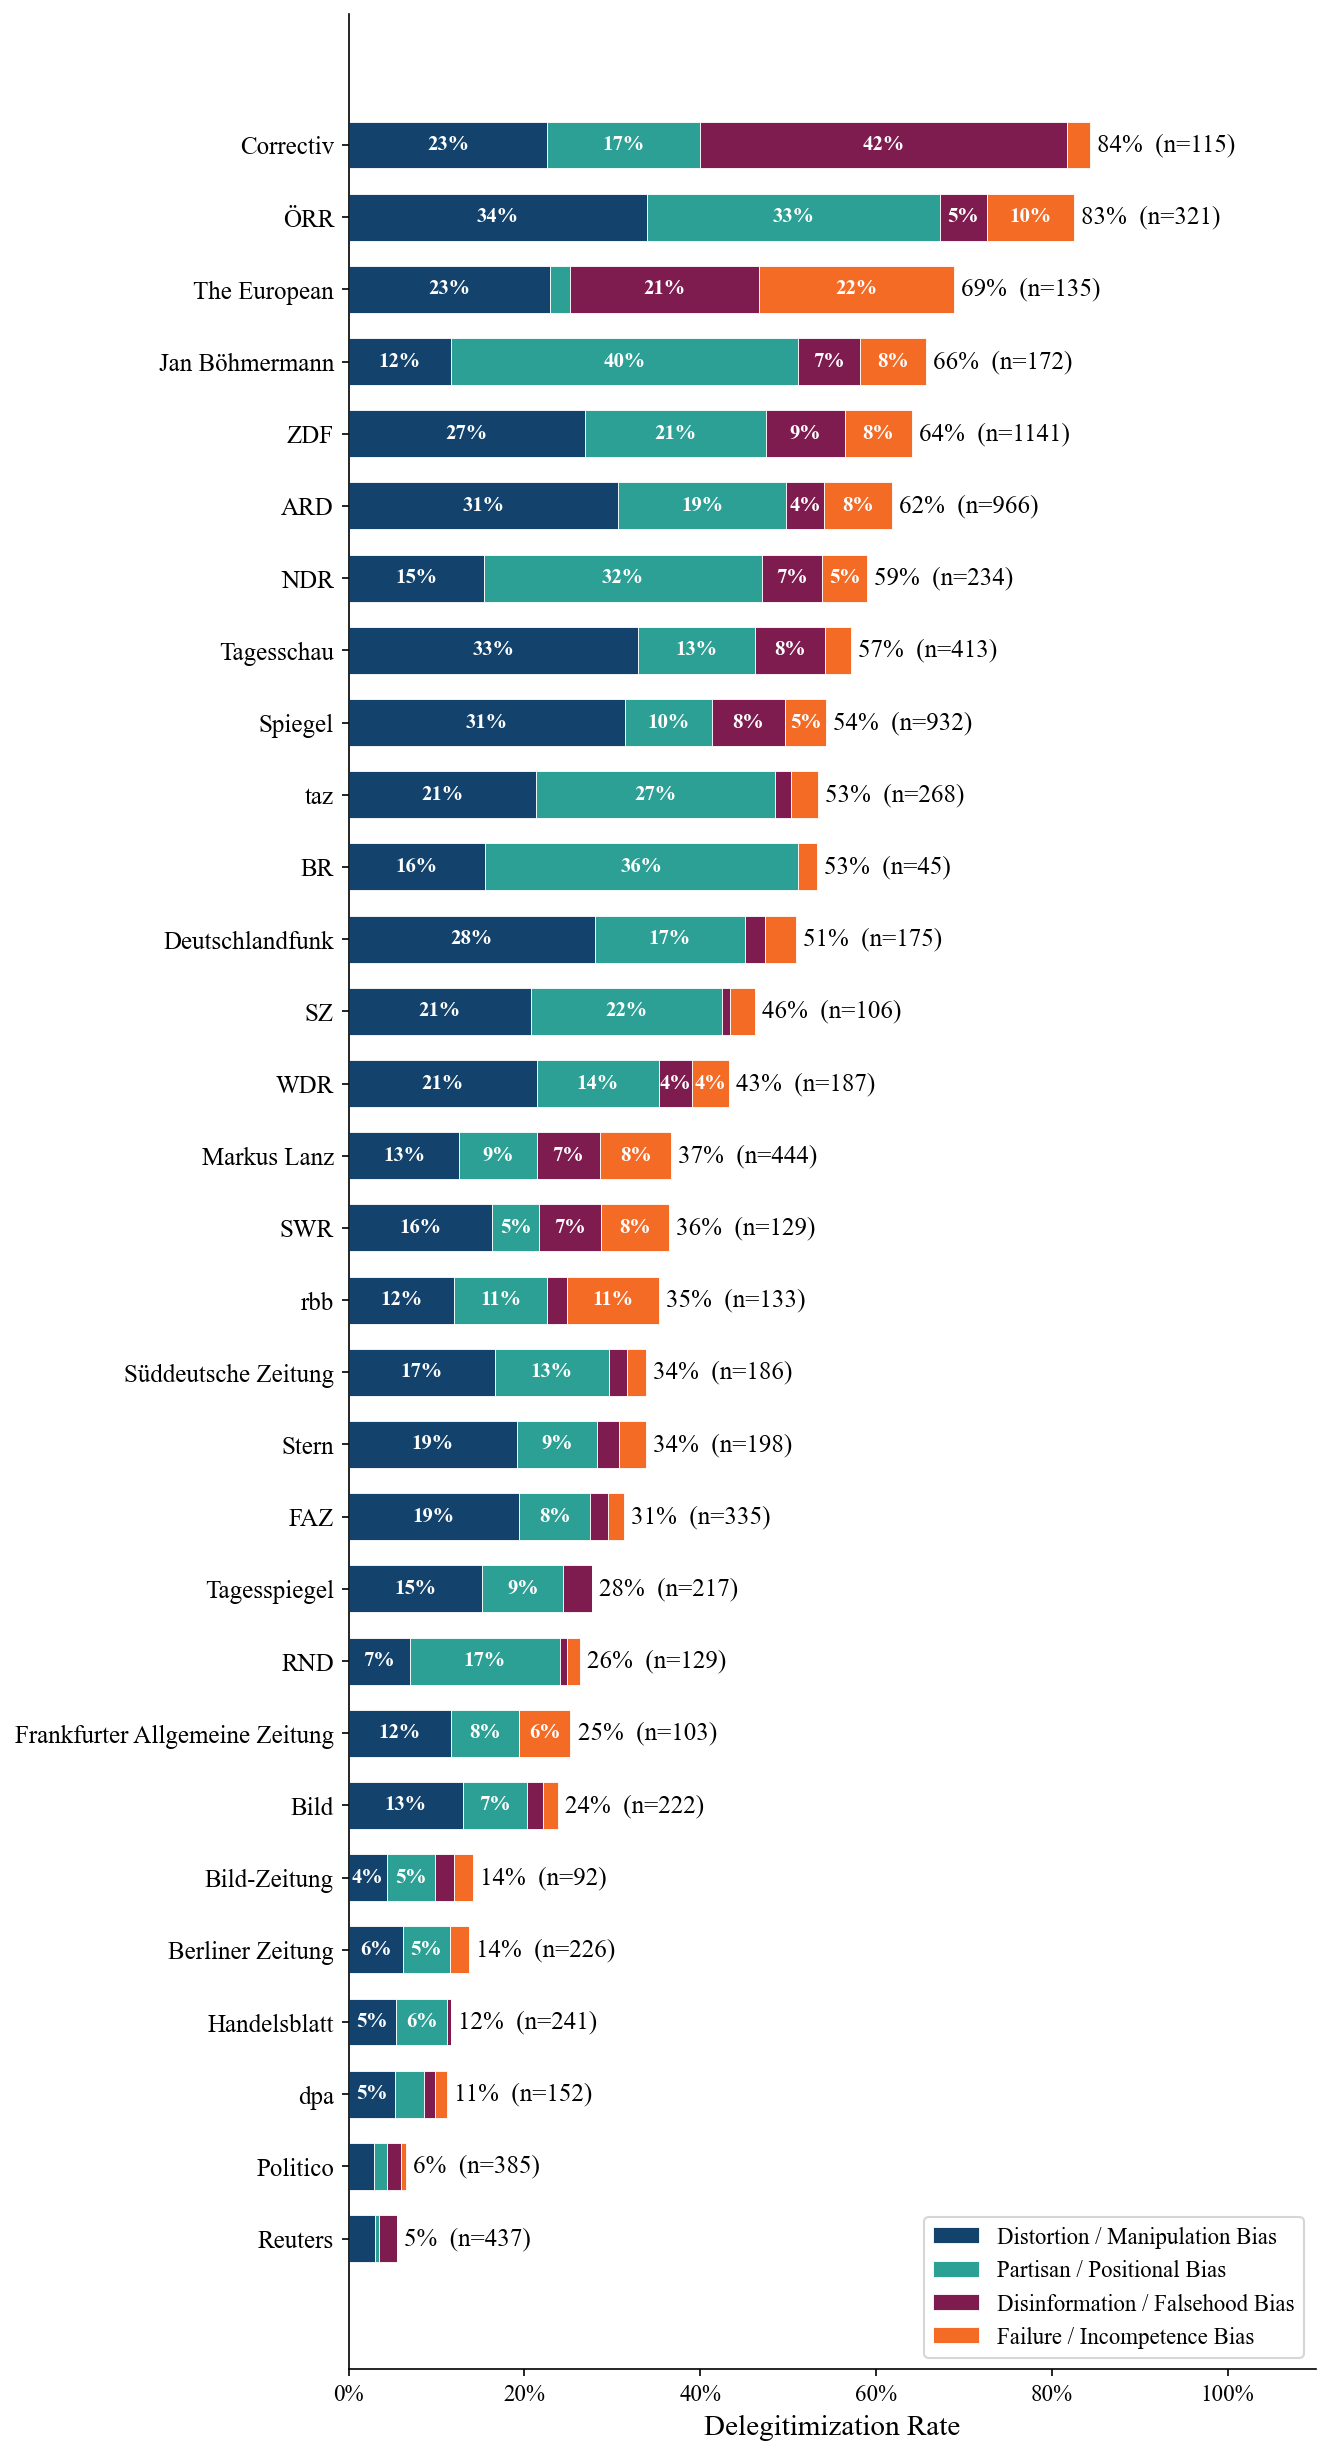

In [17]:
# ── Top 30 most-mentioned entities: delegitimisation rate stacked by bias type ─
# Same entities & order as chart above (top 30 by total hits, sorted by deleg. rate)
# Bar length = delegitimisation rate; segments = share of each bias within non-neutral hits

CATEGORY_BIAS = {
    "VERZERRUNG/MANIPULATION":            "Distortion / Manipulation Bias",
    "POSITIONS-/PARTEILICHKEITS-BIAS":    "Partisan / Positional Bias",
    "DISINFORMATION/FALSCHDARSTELLUNG":   "Disinformation / Falsehood Bias",
    "VERSAGEN/INKOMPETENZ":               "Failure / Incompetence Bias",
}
FRAME_ORDER_BIAS = [
    "Distortion / Manipulation Bias",
    "Partisan / Positional Bias",
    "Disinformation / Falsehood Bias",
    "Failure / Incompetence Bias",
]
FRAME_COLORS_BIAS = {
    "Distortion / Manipulation Bias":  "#13436d",
    "Partisan / Positional Bias":      "#2da095",
    "Disinformation / Falsehood Bias": "#7e1b4f",
    "Failure / Incompetence Bias":     "#f46b26",
}

# Build same entity set as chart above (top 30 by total mentions)
df_known2 = df[df["hit_text"].isin(hit_to_group)].copy()
df_known2["frame"] = df_known2["category"].map(CATEGORY_BIAS)

total_hits2   = df_known2.groupby("hit_text").size()
framing_hits2 = df_known2[df_known2["category"] != "NEUTRAL"].groupby("hit_text").size()
deleg2        = (framing_hits2 / total_hits2).dropna()

top_ents2     = total_hits2.nlargest(TOP_N).index
deleg2        = deleg2.reindex(top_ents2).dropna().sort_values(ascending=True)
ordered_ents  = deleg2.index.tolist()

# Frame counts per entity (as % of total hits → stacks sum to deleg. rate)
df_bias2 = df_known2[
    df_known2["hit_text"].isin(ordered_ents) &
    df_known2["category"].isin(CATEGORY_BIAS)
].copy()

frame_counts = (
    df_bias2.groupby(["hit_text", "frame"]).size()
    .unstack(fill_value=0)
    .reindex(columns=FRAME_ORDER_BIAS, fill_value=0)
)
# Divide by total_hits2 to get each segment as fraction of total (so bars = deleg. rate)
frame_rates = frame_counts.div(total_hits2, axis=0).reindex(ordered_ents).fillna(0)

fig, ax = plt.subplots(figsize=(9, max(6, len(ordered_ents) * 0.55)))

lefts = np.zeros(len(ordered_ents))
for frame in FRAME_ORDER_BIAS:
    vals = frame_rates[frame].values * 100          # → percentage points
    ax.barh(ordered_ents, vals, left=lefts,
            color=FRAME_COLORS_BIAS[frame], label=frame,
            height=0.65, edgecolor="white", linewidth=0.4)
    for i, (v, l) in enumerate(zip(vals, lefts)):
        if v >= 3.5:
            ax.text(l + v / 2, i, f"{v:.0f}%",
                    ha="center", va="center", fontsize=10,
                    color="white", fontweight="bold")
    lefts += vals

# Total deleg. rate label at end of bar
for i, (ent, left) in enumerate(zip(ordered_ents, lefts)):
    n = int(total_hits2[ent])
    ax.text(left + 0.8, i, f"{left:.0f}%  (n={n})",
            ha="left", va="center", fontsize=12)

ax.set_xlabel("Delegitimization Rate", fontsize=14)
ax.set_xlim(0, 110)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))
ax.tick_params(axis="y", labelsize=12)
ax.tick_params(axis="x", labelsize=11)
ax.spines[["top", "right"]].set_visible(False)
ax.xaxis.grid(False)
ax.legend(loc="lower right", fontsize=11, frameon=True)
plt.tight_layout()
plt.show()
